In [13]:
def subgraph_isomorphism_check(circuit, rxAG):
    if isinstance(circuit, DAGCircuit):
        qc = dag_to_circuit(circuit)
    if isinstance(circuit, QuantumCircuit):
        qc = remove_1q_and_consecutive_2q_gates_in_circuit(circuit)
        g = graph_of_circuit(qc)
        rxg = rx.networkx_converter(g)
        
    is_embeddable = rx.is_subgraph_isomorphic(rxAG, rxg, induced=False)
    if is_embeddable:
        vf2_map = rx.vf2_mapping(rxAG, rxg, subgraph=True, induced=False)
        #print(f"rx-vf2_mapping: {next(vf2_map)}")
        return is_embeddable, vf2_map
    return is_embeddable, None

In [31]:
import random
import networkx as nx
import rustworkx as rx
from dac_part import *
from qiskit.visualization import circuit_drawer
from qiskit.circuit import QuantumCircuit
from qiskit.converters import circuit_to_dag, dag_to_circuit

from ag import *


"""Test DAC"""
path = '../bench/qiskit_circuit_benchmark/' 
#filename = 'excitation_preserving_6.qasm'
#filename = 'grover_operator_14.qasm'
#filename = 'and_10.qasm'
filename = 'inner_product_6.qasm'

print(f'filename: {filename}')
AG = qgrid(2,3)
#AG = q20()

rxAG = rx.networkx_converter(AG)


#rxAG = rx.PyGraph()
#rxAG.add_nodes_from(AG.nodes())
#rxE = [(edge[0],edge[1],edge) for edge in AG.edges()]
#rxAG.add_edges_from(rxE)
print(type(rxAG))
print(rxAG.nodes())
for edge in rxAG.edge_indices():
    print(edge)

with open(path+filename, 'r') as file:
    qasm_code = file.read()

# Create a QuantumCircuit from the QASM code
qc = QuantumCircuit.from_qasm_str(qasm_code)
circuit_drawer(qc)

is_embeddable, vf2_map =  subgraph_isomorphism_check(qc, rxAG)

print(is_embeddable)
if is_embeddable:
    print(f"rx-vf2_mapping: {next(vf2_map)}")
    


filename: inner_product_6.qasm
<class 'rustworkx.PyGraph'>
[0, 1, 2, 3, 4, 5]
0
1
2
3
4
5
6
True
rx-vf2_mapping: NodeMap{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}


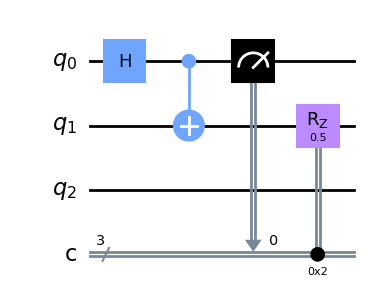

In [39]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.dagcircuit import DAGCircuit
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer, circuit_drawer

q = QuantumRegister(3, 'q')
c = ClassicalRegister(3, 'c')
circ = QuantumCircuit(q, c)
circ.h(q[0])
circ.cx(q[0], q[1])
circ.measure(q[0], c[0])
circ.rz(0.5, q[1]).c_if(c, 2)

dag = circuit_to_dag(circ)
#circuit_drawer(circ)
circ.draw('mpl')
#dag.draw('mpl')